# Genomic LLM Interpretability: Embeddings & Token Importance

In this section, we go "under the hood" of the Nucleotide Transformer to answer two questions that come up constantly when working with genomic LLMs:

1. **Where in the network does useful biological signal live?** We'll extract embeddings from every layer and see which layers best separate promoters from non-promoters.
2. **Which parts of a DNA sequence is the model actually looking at?** We'll compute a token-importance (saliency) score for individual predictions and visualize it directly on the sequence.

## 1. Setup

In [ ]:
!pip uninstall -y -q torchvision torchaudio
!pip install -q "transformers>=4.44,<5.0" datasets accelerate evaluate scikit-learn matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 19.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.27 requires torchvision, which is not installed.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import evaluate

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("GPU available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"


GPU available: True


## 2. Loading data and fine-tuning

We will fine-tune the Nucleotide Transformer (50M params) on TATA-box promoter classification.

To keep this section short, we use a small subset of the data, and a few epochs. This gives us a classifier that is noticeably better than random, which is all we need for the interpretability sections below.

In [ ]:
MODEL_CHECKPOINT = "InstaDeepAI/nucleotide-transformer-v2-50m-multi-species"

# We load the whole dataset once and then filter down to the task we want.
full_dataset = load_dataset("InstaDeepAI/nucleotide_transformer_downstream_tasks")
raw_dataset = full_dataset.filter(lambda example: example["task"] == "promoter_tata")

train_dataset = raw_dataset["train"].shuffle(seed=SEED).select(range(1000))
eval_dataset = raw_dataset["test"].shuffle(seed=SEED).select(range(200))

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

H3K9ac/train.parquet:   0%|          | 0.00/6.47M [00:00<?, ?B/s]

H3K4me1/train.parquet:   0%|          | 0.00/7.38M [00:00<?, ?B/s]

...

splice_sites_donors/test.parquet:   0%|          | 0.00/655k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/461850 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/48797 [00:00<?, ? examples/s]

Filter:   0%|          | 0/461850 [00:00<?, ? examples/s]

Filter:   0%|          | 0/48797 [00:00<?, ? examples/s]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

def tokenize_function(batch):
    return tokenizer(batch["sequence"], padding="max_length", truncation=True, max_length=64)

train_tokenized = train_dataset.map(tokenize_function, batched=True)
eval_tokenized = eval_dataset.map(tokenize_function, batched=True)
train_tokenized = train_tokenized.rename_column("label", "labels")
eval_tokenized = eval_tokenized.rename_column("label", "labels")

columns_to_keep = ["input_ids", "attention_mask", "labels"]
train_tokenized.set_format(type="torch", columns=columns_to_keep)
eval_tokenized.set_format(type="torch", columns=columns_to_keep)

tokenizer_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT, num_labels=2, trust_remote_code=True
).to(device)


config.json: 0.00B [00:00, ?B/s]

esm_config.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-50m-multi-species:
- esm_config.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_esm.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/nucleotide-transformer-v2-50m-multi-species:
- modeling_esm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/224M [00:00<?, ?B/s]

Some weights of the model checkpoint at InstaDeepAI/nucleotide-transformer-v2-50m-multi-species were not used when initializing EsmForSequenceClassification: ['lm_head.bias', 'lm_head.decoder.weight', 'lm_head.dense.bias', 'lm_head.dense.weight', 'lm_head.layer_norm.bias', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing EsmForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing EsmForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of EsmForSequenceClassification were not initialized from the model checkpoint at InstaDeepAI/nucleotide-transformer-v2-50m-multi-species and are newly initialized: ['classifier.dense.bias', 'c

In [ ]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=predictions, references=labels)

training_args = TrainingArguments(
    output_dir="./nt-quick-finetune",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=25,
    report_to="none",
    fp16=torch.cuda.is_available(), # Enable fp16 if we have a GPU available
    # Mixed-precision training: https://medium.com/@dpratishraj7991/mixed-precision-training-in-llms-fp16-bf16-fp8-and-beyond-b4af13ca846f
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=eval_tokenized,
    compute_metrics=compute_metrics,
)

trainer.train()
print(trainer.evaluate())


Epoch,Training Loss,Validation Loss,Accuracy
1,0.331800,0.377806,0.860000
2,0.074700,0.415585,0.900000
3,0.055200,0.462043,0.900000


{'eval_loss': 0.46204322576522827, 'eval_accuracy': 0.9, 'eval_runtime': 0.5265, 'eval_samples_per_second': 379.876, 'eval_steps_per_second': 47.485, 'epoch': 3.0}


## 3. Extracting embeddings from every layer

Transformer models like the Nucleotide Transformer don't have just one "embedding" — every layer produces its own representation of the sequence, and these evolve as information flows through the network.

Passing `output_hidden_states=True` gives us a tuple with one tensor per layer (plus the initial input embedding layer), each of shape `(batch_size, sequence_length, hidden_size)`.

Pooling each layer's token-level representations into a single vector per sequence results in one embedding vector *per layer, per sequence*.  We can do this by mean-pooling over non-padded tokens.

In [ ]:
def get_layerwise_embeddings(sequences, batch_size=8, max_length=64):
    # Returns a list of arrays, one per layer, each of shape (num_sequences, hidden_size).
    model.eval()
    all_layers_embeddings = None

    for start in range(0, len(sequences), batch_size):
        batch_seqs = sequences[start:start + batch_size]
        inputs = tokenizer(
            batch_seqs, return_tensors="pt", padding="max_length",
            truncation=True, max_length=max_length,
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs, output_hidden_states=True)

        hidden_states = outputs.hidden_states  # tuple: (num_layers + 1) x (batch, seq_len, hidden)
        mask = inputs["attention_mask"].unsqueeze(-1)  # (batch, seq_len, 1)

        if all_layers_embeddings is None:
            all_layers_embeddings = [[] for _ in hidden_states]

        for layer_idx, layer_hidden in enumerate(hidden_states):
            # Mean-pool over real (non-padding) tokens only
            summed = (layer_hidden * mask).sum(dim=1)
            counts = mask.sum(dim=1).clamp(min=1)
            pooled = (summed / counts).cpu().numpy()
            all_layers_embeddings[layer_idx].append(pooled)

    return [np.concatenate(layer_chunks, axis=0) for layer_chunks in all_layers_embeddings]


# Run on a modest subset of the eval set for speed
probe_sequences = eval_dataset["sequence"][:150]
probe_labels = np.array(eval_dataset["label"][:150])

layer_embeddings = get_layerwise_embeddings(probe_sequences)
print(f"Number of layers (including input embeddings): {len(layer_embeddings)}")
print(f"Shape of each layer's embeddings: {layer_embeddings[0].shape}")


Number of layers (including input embeddings): 13
Shape of each layer's embeddings: (150, 512)


## 4. Layer-wise probing: where does the useful signal live?

A common way to study what a pretrained model has learned at each depth is **probing**: freeze the embeddings from a given layer and train a small, simple classifier (here, logistic regression) on top of them. If a layer's embeddings are more separable, that layer encodes more task-relevant information.

We'll split our probing sequences into a small train/test split, then fit one logistic regression probe per layer and plot accuracy vs. depth.

Reading material: https://arxiv.org/abs/1905.05950

In [ ]:
n_probe = len(probe_labels)
split = int(n_probe * 0.7)

layer_accuracies = []
for layer_idx, embeddings in enumerate(layer_embeddings):
    X_train, X_test = embeddings[:split], embeddings[split:]
    y_train, y_test = probe_labels[:split], probe_labels[split:]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train, y_train)
    acc = probe.score(X_test, y_test)
    layer_accuracies.append(acc)

for i, acc in enumerate(layer_accuracies):
    layer_name = "Input embeddings" if i == 0 else f"Layer {i}"
    print(f"{layer_name:>18}: {acc:.3f} accuracy")


  Input embeddings: 0.578 accuracy
           Layer 1: 0.778 accuracy
           Layer 2: 0.844 accuracy
           Layer 3: 0.822 accuracy
           Layer 4: 0.889 accuracy
           Layer 5: 0.889 accuracy
           Layer 6: 0.889 accuracy
           Layer 7: 0.867 accuracy
           Layer 8: 0.844 accuracy
           Layer 9: 0.822 accuracy
          Layer 10: 0.822 accuracy
          Layer 11: 0.867 accuracy
          Layer 12: 0.844 accuracy


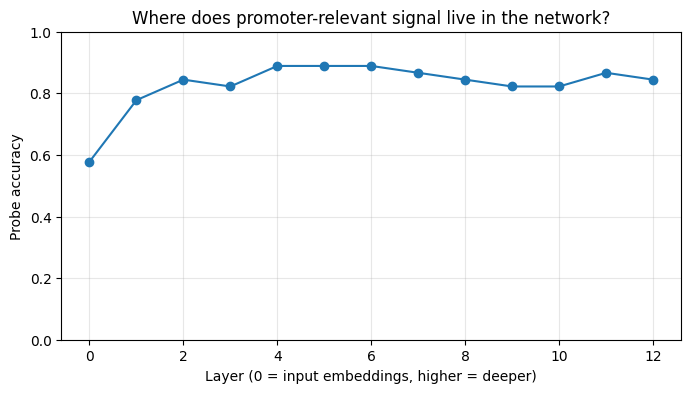

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(len(layer_accuracies)), layer_accuracies, marker="o")
plt.xlabel("Layer (0 = input embeddings, higher = deeper)")
plt.ylabel("Probe accuracy")
plt.title("Where does promoter-relevant signal live in the network?")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

**What to look for:**
- If accuracy rises through the middle/later layers, that suggests the model builds up task-relevant structure as depth increases. This is consistent with how transformer LLMs are generally understood to compose lower-level features (like local sequence motifs) into higher-level ones.
- If accuracy is flat or drops near the very last layer, that's often because the final layer is specialised for the model's original pretraining objective (masked-token prediction) rather than for classification. Hence, fine-tuning can improve results even when using strong pretrained embeddings.

### Understanding Uncertainty
The above computes one accuracy per layer. Here, we demonstrate two techniques that can be used to understand the uncertainty in these values.

#### 1. Bootstrapping
Here, we resample the test set with replacement (500 iterations) and recompute the probe accuracy for each resample. We then use the resulting distribution of accuracies to estimate the 95% confidence interval by taking the 2.5th and 97.5th percentiles.

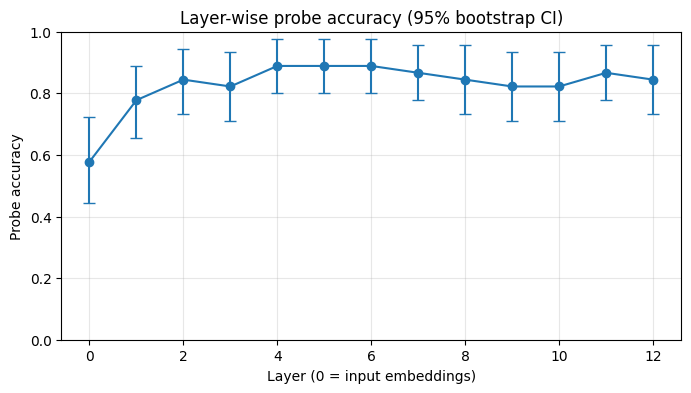

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

n_boot = 500

layer_means = []
layer_err_low = []
layer_err_high = []

for embeddings in layer_embeddings:
    X_train, X_test = embeddings[:split], embeddings[split:]
    y_train, y_test = probe_labels[:split], probe_labels[split:]

    probe = LogisticRegression(max_iter=1000)
    probe.fit(X_train, y_train)

    preds = probe.predict(X_test)
    acc = accuracy_score(y_test, preds)
    layer_means.append(acc)

    # Bootstrap the test set
    boot_accs = []
    rng = np.random.default_rng(42)

    for _ in range(n_boot):
        idx = rng.choice(len(y_test), len(y_test), replace=True)
        boot_accs.append(
            accuracy_score(y_test[idx], preds[idx])
        )

    lower = np.percentile(boot_accs, 2.5)
    upper = np.percentile(boot_accs, 97.5)

    layer_err_low.append(acc - lower)
    layer_err_high.append(upper - acc)

plt.figure(figsize=(8,4))
plt.errorbar(
    range(len(layer_means)),
    layer_means,
    yerr=[layer_err_low, layer_err_high],
    fmt='o-',
    capsize=4
)

plt.xlabel("Layer (0 = input embeddings)")
plt.ylabel("Probe accuracy")
plt.title("Layer-wise probe accuracy (95% bootstrap CI)")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

#### 2. Cross-Validation
We replace the single train-test split with 5-fold stratified cross-validation. We then plot the mean and standard deviation across folds.

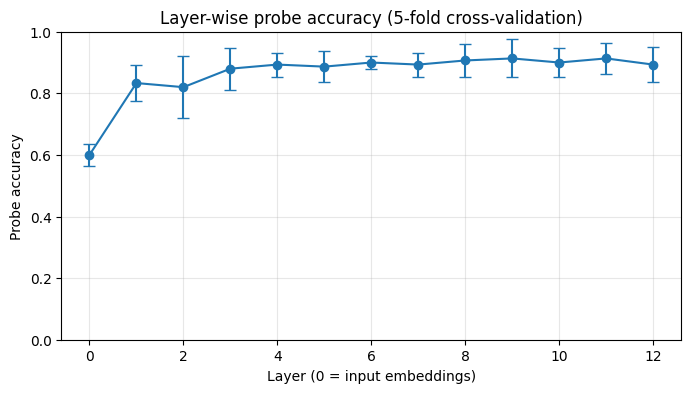

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import numpy as np

# Number of folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

layer_means = []
layer_stds = []

for embeddings in layer_embeddings:

    clf = LogisticRegression(max_iter=1000)

    scores = cross_val_score(
        clf,
        embeddings,
        probe_labels,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    layer_means.append(scores.mean())
    layer_stds.append(scores.std())

plt.figure(figsize=(8,4))

plt.errorbar(
    range(len(layer_means)),
    layer_means,
    yerr=layer_stds,
    fmt='o-',
    capsize=4
)

plt.xlabel("Layer (0 = input embeddings)")
plt.ylabel("Probe accuracy")
plt.title("Layer-wise probe accuracy (5-fold cross-validation)")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.show()

## 5. Visualizing embeddings with PCA

Numbers on a plot are useful, but *seeing* the separation between classes is often more intuitive.

We will take an early layer and a late layer, reduce each to 2 dimensions with PCA, and plot the sequences colored by their true label.

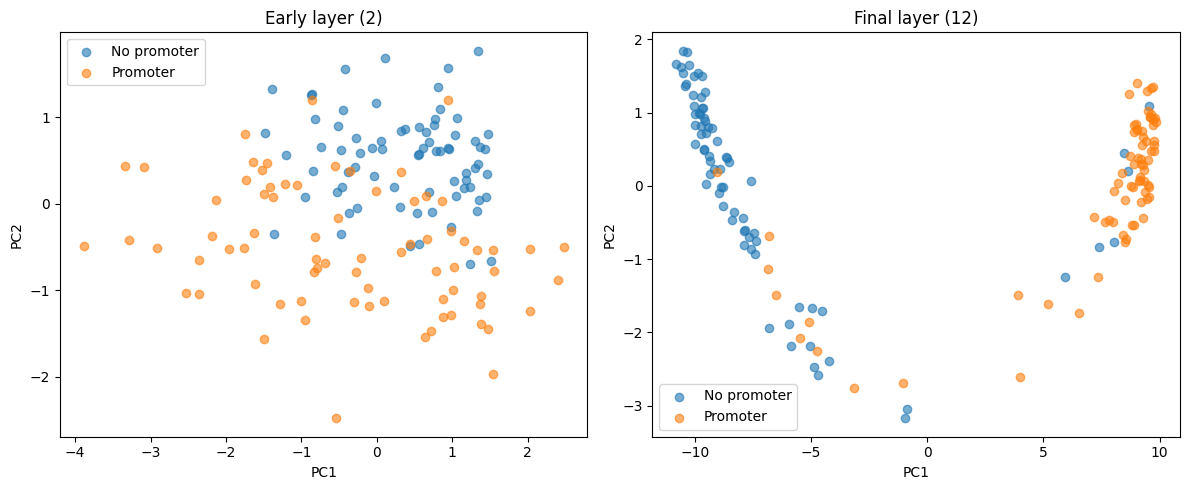

In [ ]:
early_layer_idx = 2
late_layer_idx = len(layer_embeddings) - 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, layer_idx, title in [
    (axes[0], early_layer_idx, f"Early layer ({early_layer_idx})"),
    (axes[1], late_layer_idx, f"Final layer ({late_layer_idx})"),
]:
    pca = PCA(n_components=2, random_state=SEED)
    coords = pca.fit_transform(layer_embeddings[layer_idx])

    for label_value, label_name, color in [(0, "No promoter", "tab:blue"), (1, "Promoter", "tab:orange")]:
        mask = probe_labels == label_value
        ax.scatter(coords[mask, 0], coords[mask, 1], label=label_name, alpha=0.6, c=color)

    ax.set_title(title)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()

plt.tight_layout()
plt.show()


If fine-tuning and the model are working well, you should see noticeably tighter, more separated clusters in the final-layer plot compared to the early-layer plot.

## 6. Token importance: what is the model actually looking at?

Let's zoom into a single prediction and ask: *which parts of this specific DNA sequence drove the model's decision?*

We'll use a classic and simple technique called **Gradient × Input** saliency:
1. Run the sequence through the model and pick the predicted class's logit as our "score"
2. Backpropagate that score all the way to the input token embeddings
3. Multiply each token's embedding by its own gradient and sum across the embedding dimension — this gives one importance score per token

Intuitively: a token gets a high score if (a) the model's output is sensitive to changes in that token's embedding, and (b) the embedding itself has magnitude in the directions that matter. This is a simple approximation that is a common starting point before moving to more advanced attribution methods such as Integrated Gradients, SHAP, attention rollout, etc.

In [ ]:
def compute_token_saliency(sequence: str, max_length: int = 64):
    inputs = tokenizer(sequence, return_tensors="pt", truncation=True, max_length=max_length).to(device)

    embedding_layer = model.get_input_embeddings()
    captured = {}

    def hook(module, module_input, module_output):
        module_output.retain_grad()
        captured["embeds"] = module_output

    handle = embedding_layer.register_forward_hook(hook)

    model.eval()
    model.zero_grad()
    outputs = model(**inputs)
    logits = outputs.logits
    predicted_class = int(logits.argmax(dim=-1))
    score = logits[0, predicted_class]
    score.backward()

    embeds = captured["embeds"]              # (1, seq_len, hidden)
    grads = embeds.grad                       # (1, seq_len, hidden)
    saliency = (grads * embeds).sum(dim=-1).abs()[0]  # (seq_len,)
    saliency = saliency.detach().cpu().numpy()

    handle.remove()

    token_ids = inputs["input_ids"][0].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(token_ids)

    # Drop special tokens (e.g. <cls>) and padding from the visualization
    keep = [i for i, t in enumerate(tokens) if t not in tokenizer.all_special_tokens]
    tokens = [tokens[i] for i in keep]
    saliency = saliency[keep]

    # Normalize to [0, 1] for coloring
    if saliency.max() > saliency.min():
        saliency_norm = (saliency - saliency.min()) / (saliency.max() - saliency.min())
    else:
        saliency_norm = np.zeros_like(saliency)

    predicted_label = "Promoter" if predicted_class == 1 else "No promoter"
    return tokens, saliency_norm, predicted_label


In [ ]:
from IPython.display import HTML, display

def render_saliency_html(tokens, saliency_norm, predicted_label):
    spans = []
    for tok, score in zip(tokens, saliency_norm):
        # Red intensity scales with importance
        color = f"rgba(220, 20, 60, {score:.2f})"
        spans.append(
            f'<span style="background-color:{color}; padding:2px 3px; margin:1px; '
            f'border-radius:3px; font-family:monospace;">{tok}</span>'
        )
    html = f"<b>Prediction: {predicted_label}</b><br>" + "".join(spans)
    display(HTML(html))


# Try it on a real example from the eval set
example_idx = 0
example_sequence = eval_dataset["sequence"][example_idx]
true_label = "Promoter" if eval_dataset["label"][example_idx] == 1 else "No promoter"

tokens, saliency_norm, predicted_label = compute_token_saliency(example_sequence)
print(f"True label: {true_label}")
render_saliency_html(tokens, saliency_norm, predicted_label)


True label: No promoter


In [ ]:
# Also try it on our synthetic TATA-box example from Part 1 to see if the model
# highlights the motif region itself.
tata_example = ("GC" * 40 + "TATAAA" + "GC" * 40)[:300]
tokens, saliency_norm, predicted_label = compute_token_saliency(tata_example)
print("Synthetic sequence with an inserted TATAAA motif")
render_saliency_html(tokens, saliency_norm, predicted_label)


Synthetic sequence with an inserted TATAAA motif


**What to look for:** since the tokenizer groups DNA into 6-mer chunks, look for a darker-highlighted token around where the `TATAAA` motif was inserted. A well-fine-tuned model often (though not always, especially with only 1 epoch of quick training) assigns higher importance to tokens overlapping known motifs — this is exactly the kind of sanity check researchers use to build trust in a genomic model's predictions before applying it to novel sequences.

### A note on interpretability methods
Gradient × Input is simple but has known limitations — it can be noisy and is sensitive to how "flat" or "sharp" the model's function is around a given input. If you want to go further:
- **Integrated Gradients** averages gradients along a path from a baseline (e.g. all-padding) input to the real input, which is more robust
- **Attention visualization** looks at the transformer's attention weights directly (`output_attentions=True`) rather than gradients
- The [`captum`](https://captum.ai/) library implements many of these methods off-the-shelf for PyTorch models


## Wrap-up

In this notebook you:
- Extracted embeddings from **every layer** of a genomic LLM, not just the last one
- Used **layer-wise probing** to see where in the network promoter-relevant signal is most linearly separable
- Visualized how embeddings separate by class using PCA
- Computed and visualized **token-level importance** for individual predictions using Gradient × Input saliency
